# Replication of Rosenstock, Bruner & O'Connor (2017)

**Reference:** Rosenstock, S., Bruner, J., & O'Connor, C. (2017). In Epistemic Networks, Is Less Really More? *Philosophy of Science*, 84(2), 234–252.

**Main claim:** Zollman's result is not robust: as the difference between objective probabilities increases, as the number of pulls per step increases, or as the number of agents increases, the advantage of sparser networks diminishes or disappears.

**Note**: Rosentock et al. use the 2007 version of the Zollman model, which is slightley different in that agents which believe that the B theory is correct, stop researching althogheter, as its success rate is supposed to be already established at 0.5, unless they are presented with evidence that the A theory is better. Moreover, the prior beliefs and update of beliefs was implemented differently, further distancing the two versions. Here we see if their results hold for the 2010 version of the model, trying to preserve their parameter chioces.

In [1]:
import sys
import os
from pathlib import Path

# Ensure repo root is in the Python path
sys.path.insert(0, os.path.abspath('..'))

In [ ]:
import mesa
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scripts.model import Bandit

## Model parameters

| Parameter | Analysis 1 | Analysis 2 | Analysis 3 | Original paper | Notes |
|---|---|---|---|---|---|
| n | 10 | 10 | [10, 20, 40, 80] | - | In analysis 3 the range was shortened from 100 to 80 and less granual definition was used to save compute time|
| a_objective | np.arange(.501,.610,.010) | 0.51 | 0.501 | - | In analysis 1 the max range was cutted at .6 instead of going up to 1|
| b_objective | 0.5 | 0.5 | 0.5 | identical | differs from Zollman 2010 (.499) |
| max_priors | 1000 | 1000 | 1000 | Not given | The 2007 model used a random belief value comprised between 0 and 1 as prior |
| step_pulls | 1000 | range(1000,11000,1000) | 1000 | identical | |
| graph | complete, cycle | complete, cycle | complete, cycle | identical | wheel excluded |
| iterations | 1000 | 1000 | 1000 | 10000 | sufficient for statistical purposes |
| max_steps | 10000 | 10000 | 10000 | identical | |

**Deviations from original:** Since the 2010 model was used, the max_priors value was set to 1000 keeping it as a middle ground. Moreover, we always used a less fine grained resolution and perfomed less iterations to save some compute time.

## Analysis 1 — Varying objective probability

As the difference between the objective probabilities of A and B increases (a_objective from 0.501 to 0.60, b_objective fixed at 0.5), does the advantage of the cycle graph over the complete graph diminish?

In [ ]:
parameters_1 = {
    "n": 10,
    "a_objective": list(np.arange(0.501, 0.555, 0.005)),
    "b_objective": 0.5,
    "max_priors": 500,
    "graph": ["complete", "cycle"],
    "theory_threshold": 0,
    "step_pulls": 1000,
    "dynamic": None,
    "criticism": False,
    "inertia": 0,
    "seed": None
}

results_1 = mesa.batch_run(
    Bandit,
    parameters=parameters_1,
    iterations=1000,
    max_steps=10000
)

df_1 = pd.DataFrame(results_1)
Path("results/Rosenstock_et_al_replication/").mkdir(parents=True, exist_ok=True)
df_1.to_csv("results/Rosenstock_et_al_replication/increasing_a_objective.csv")

  0%|          | 0/20000 [00:00<?, ?it/s]

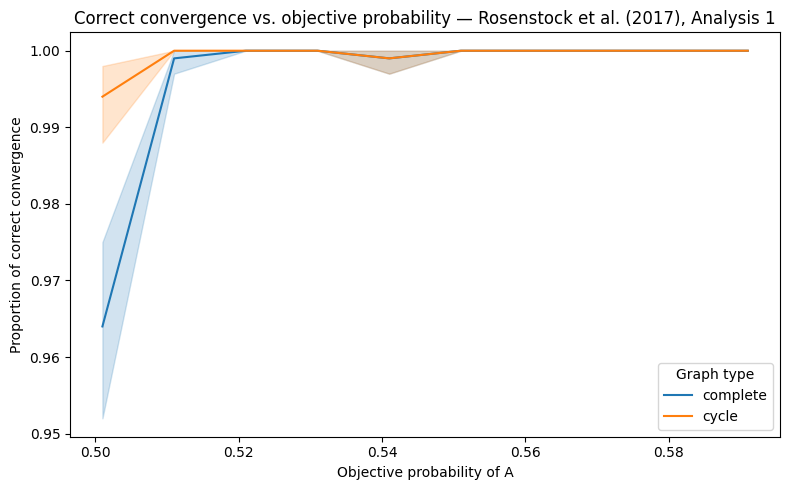

In [4]:
df_1 = pd.read_csv("results/Rosenstock_et_al_replication/increasing_a_objective.csv")
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_1, x="a_objective", y="Correct Convergence",
             hue="graph", ax=ax)
ax.set_title("Correct convergence vs. objective probability — Rosenstock et al. (2017), Analysis 1")
ax.set_xlabel("Objective probability of A")
ax.set_ylabel("Proportion of correct convergence")
ax.legend(title="Graph type")
plt.tight_layout()
plt.savefig("results/Rosenstock_et_al_replication/increasing_a_objective")
plt.show()

**Result:** [Da compilare dopo l'esecuzione]

## Analysis 2 — Varying pulls per step

As the number of pulls per step increases (1000 to 9000, making experimental evidence more reliable), does the advantage of sparser networks diminish?

In [ ]:
parameters_2 = {
    "n": 10,
    "a_objective": 0.51,
    "b_objective": 0.5,
    "max_priors": 500,
    "graph": ["complete", "cycle"],
    "theory_threshold": 0,
    "step_pulls": list(range(1000, 11000, 1000)),
    "dynamic": None,
    "criticism": False,
    "inertia": 0,
    "seed": None
}

results_2 = mesa.batch_run(
    Bandit,
    parameters=parameters_2,
    iterations=1000,
    max_steps=10000
)

df_2 = pd.DataFrame(results_2)
Path("results/Rosenstock_et_al_replication/").mkdir(parents=True, exist_ok=True)
df_2.to_csv("results/Rosenstock_et_al_replication/increasing_step_pulls.csv")

  0%|          | 0/20000 [00:00<?, ?it/s]

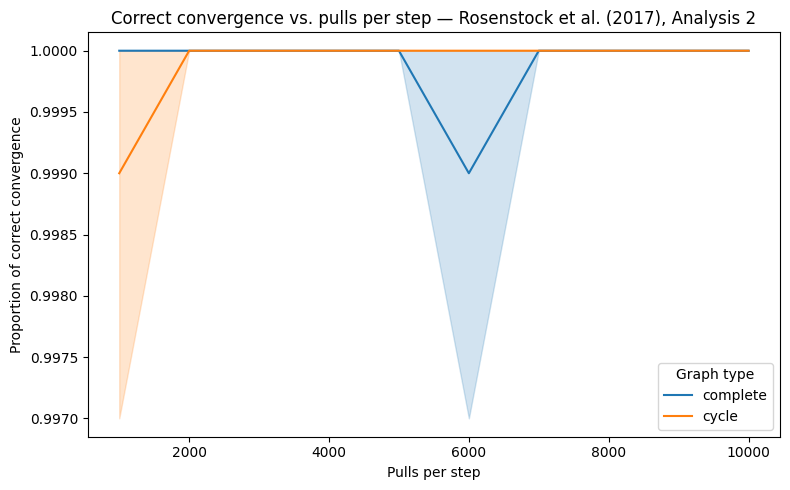

In [6]:
df_2 = pd.read_csv("results/Rosenstock_et_al_replication/increasing_step_pulls.csv")
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_2, x="step_pulls", y="Correct Convergence",
             hue="graph", ax=ax)
ax.set_title("Correct convergence vs. pulls per step — Rosenstock et al. (2017), Analysis 2")
ax.set_xlabel("Pulls per step")
ax.set_ylabel("Proportion of correct convergence")
ax.legend(title="Graph type")
plt.tight_layout()
plt.savefig("results/Rosenstock_et_al_replication/increasing_step_pulls")
plt.show()

**Result:** [Da compilare dopo l'esecuzione]

## Analysis 3 — Varying number of agents

As community size increases (n = 10, 20, 40, 80), how does network type affect correct convergence frequency?

In [ ]:
parameters_3 = {
    "n": [10, 20, 40, 80],
    "a_objective": 0.501,
    "b_objective": 0.5,
    "max_priors": 500,
    "graph": ["complete", "cycle"],
    "theory_threshold": 0,
    "step_pulls": 1000,
    "dynamic": None,
    "criticism": False,
    "inertia": 0,
    "seed": None
}

results_3 = mesa.batch_run(
    Bandit,
    parameters=parameters_3,
    iterations=1000,
    max_steps=10000
)

df_3 = pd.DataFrame(results_3)
Path("results/Rosenstock_et_al_replication/").mkdir(parents=True, exist_ok=True)
df_3.to_csv("results/Rosenstock_et_al_replication/increasing_n_agents.csv")

  0%|          | 0/8000 [00:00<?, ?it/s]

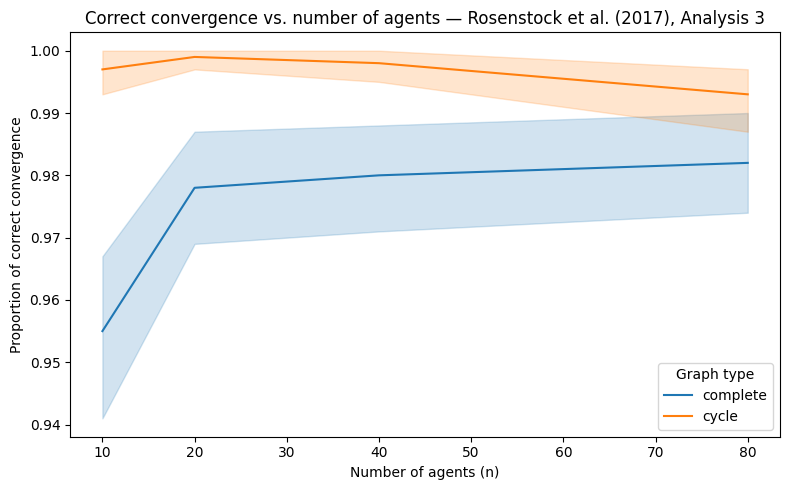

In [8]:
df_3 = pd.read_csv("results/Rosenstock_et_al_replication/increasing_n_agents.csv")
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_3, x="n", y="Correct Convergence",
             hue="graph", ax=ax)
ax.set_title("Correct convergence vs. number of agents — Rosenstock et al. (2017), Analysis 3")
ax.set_xlabel("Number of agents (n)")
ax.set_ylabel("Proportion of correct convergence")
ax.legend(title="Graph type")
plt.tight_layout()
plt.savefig("results/Rosenstock_et_al_replication/increasing_n_agents")
plt.show()

**Result:** [Da compilare dopo l'esecuzione]

**Result of investigation:** [Da compilare dopo l'esecuzione]

## Discrepancies

| Analysis | Claim | Expected | Obtained | Likely cause |
|---|---|---|---|---|
| 3 | Complete graph convergence at large n | [PLACEHOLDER] | [PLACEHOLDER] | [PLACEHOLDER] |

## Conclusions

[Da compilare dopo l'esecuzione]

The replication [successfully / partially / does not] reproduce the main claims of Rosenstock et al. (2017). [Summary dei risultati per ciascuna analisi]